In [5]:
import pandas as pd
import importlib
import numpy as np
import lib.preprocessing as pre

In [6]:
importlib.reload(pre)

goods_df = pd.read_excel('data/marked.xlsx', sheet_name='Data_new')
goods_df.head()

,name,store,predictions,target_cat,target
0,Салатный микс «Белая дача» Модена,ярче,фрукты/орехи/овощи,овощи,3
1,Салат Кейл,ярче,фрукты/орехи/овощи,овощи,3
2,Лонган,ярче,прочее,фрукты,1
3,Шпинат «Белая дача»,ярче,фрукты/орехи/овощи,овощи,3
4,Салатный микс «Белая дача» Аликанте,ярче,фрукты/орехи/овощи,овощи,3


In [7]:
cat_df = pd.read_excel('data/full_marked.xlsx', sheet_name='Category')
cat_df.head()

,Категория,Номер категории,Синоним 1,Синоним 2,Синоним 3,Синоним 4,Синоним 5,Синоним 6,Синоним 7,Синоним 8,Синоним 9,Синоним 10
0,"молоко, кефир, йогурт",0,молоко,кефир,йогурт,сметана,айран,молочный коктейль,творог,NaN,NaN,NaN
1,фрукты,1,яблоки,груши,виноград,персики,нектарины,слива,ананас,дыня,NaN,NaN
2,ягоды,2,Арбуз,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,овощи,3,салат,лук,мята,фасоль,капуста,перец,томат,огурец,картофель,чеснок
4,орехи,4,ядра тыквы,семечки,фисташки,орехи,арахис,кедровые,миндаль,NaN,NaN,NaN


In [8]:
names_list = pre.preprocess_names_list(goods_df['name'].tolist())
goods_df['name'] = names_list
goods_df

[nltk_data] Downloading package stopwords to ./lib/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
100%|██████████| 7687/7687 [00:00<00:00, 103864.49it/s]


,name,store,predictions,target_cat,target
0,салатный микс модена,ярче,фрукты/орехи/овощи,овощи,3
1,салат кейл,ярче,фрукты/орехи/овощи,овощи,3
2,лонган,ярче,прочее,фрукты,1
3,шпинат,ярче,фрукты/орехи/овощи,овощи,3
4,салатный микс аликанте,ярче,фрукты/орехи/овощи,овощи,3
...,...,...,...,...,...
7682,мини-круассаны сливочным кремом яшкино,магнит,NaN,выпечка,23
7683,мини-круассаны яшкино клубничным джемом,магнит,NaN,выпечка,23
7684,хлебные палочки grissini томатом baker house,магнит,NaN,выпечка,23
7685,соломка солёная чудесный край,магнит,NaN,выпечка,23


In [9]:
categories = pre.return_categories_list(cat_df)
print(categories)

[['молоко, кефир, йогурт', 'молоко', 'кефир', 'йогурт', 'сметана', 'айран', 'молочный коктейль', 'творог'], ['фрукты', 'яблоки', 'груши', 'виноград', 'персики', 'нектарины', 'слива', 'ананас', 'дыня'], ['ягоды', 'Арбуз'], ['овощи', 'салат', 'лук', 'мята', 'фасоль', 'капуста', 'перец', 'томат', 'огурец', 'картофель', 'чеснок'], ['орехи', 'ядра тыквы', 'семечки', 'фисташки', 'орехи', 'арахис', 'кедровые', 'миндаль'], ['грибы', 'шампиньоны', 'вешенки'], ['сладости', 'молоко сгущеное', 'сырок', 'крем', 'десерт', 'пуддинг', 'желе', 'карамель', 'пирожное', 'шоколад', 'конфеты'], ['кофе', 'кофе'], ['вода', 'вода', 'минераьная вода', 'вода питьевая'], ['сахар', 'сахар'], ['чай', 'чай', 'чайный напиток'], ['сухие завтраки', 'мюсли', 'хлопья', 'готовый завтрак', 'каша', 'овсянка'], ['хлеб', 'хлеб', 'сушки', 'баранки', 'багет', 'чиабатта', 'хлебцы', 'булочка', 'сухарики'], ['масло', 'масло', 'маргарин'], ['сыр'], ['одноразовая посуда'], ['хозяйственное'], ['аптека'], ['канцелярия'], ['прочее'], [

In [10]:
import torch
from tqdm import tqdm
from transformers import AutoTokenizer, AutoModel
tokenizer = AutoTokenizer.from_pretrained("cointegrated/rubert-tiny2", cache_dir='models')
model = AutoModel.from_pretrained("cointegrated/rubert-tiny2", cache_dir='models')

def embed_bert_cls(text, model, tokenizer):
    t = tokenizer(text, padding=True, truncation=True, return_tensors='pt')
    with torch.no_grad():
        model_output = model(**{k: v.to(model.device) for k, v in t.items()})
    embeddings = model_output.last_hidden_state[:, 0, :]
    embeddings = torch.nn.functional.normalize(embeddings)
    return embeddings[0].cpu().numpy()

In [11]:
goods_embeddings = []
category_embeddings = []

for name in tqdm(goods_df['name'].tolist()):
    goods_embeddings.append(embed_bert_cls(name, model, tokenizer))
goods_embeddings = np.array(goods_embeddings)
print(goods_embeddings.shape)


for category in tqdm(categories):
    category_embeddings.append(embed_bert_cls(category, model, tokenizer))
category_embeddings = np.array(category_embeddings)
print(category_embeddings.shape)

100%|██████████| 7687/7687 [00:30<00:00, 255.47it/s]


(7687, 312)


100%|██████████| 25/25 [00:00<00:00, 238.71it/s]

(25, 312)


In [12]:
from sklearn.metrics.pairwise import cosine_similarity

print(goods_df['name'].tolist()[0])
print(cosine_similarity([goods_embeddings[0]], category_embeddings))
embeddings = goods_embeddings

салатный микс модена
[[0.63400006 0.71392876 0.70490664 0.67162794 0.7095257  0.6858296
  0.72814286 0.7233867  0.60474384 0.72406715 0.7239846  0.72205645
  0.6650137  0.72829264 0.717172   0.7564682  0.6694446  0.65596044
  0.6673689  0.61392915 0.7016555  0.6995801  0.6585492  0.7382972
  0.7912513 ]]


In [13]:
import hdbscan

clustered = hdbscan.HDBSCAN(min_cluster_size=2, metric='euclidean')
labels = clustered.fit_predict(embeddings)

C:\Users\Admin\Documents\Study\Projects\7_semester\MDP\mdp_venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Admin\Documents\Study\Projects\7_semester\MDP\mdp_venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


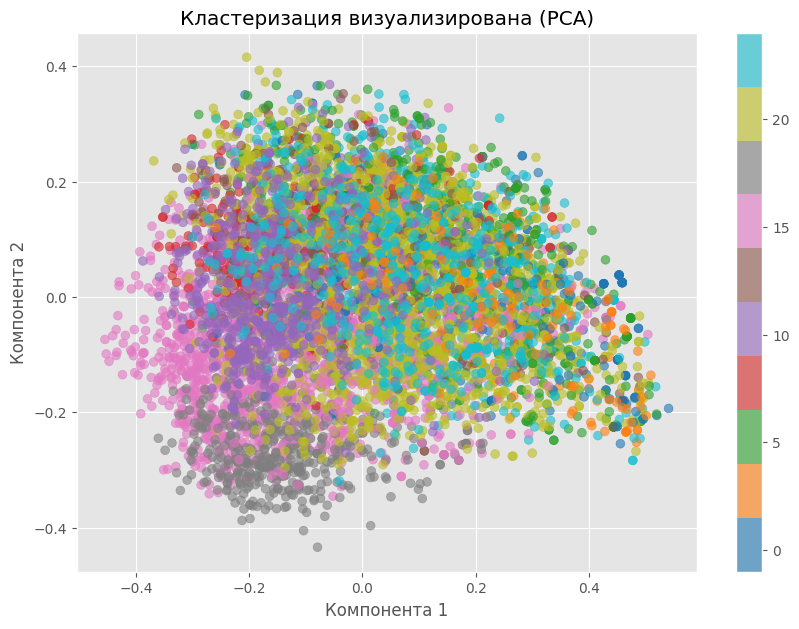

C:\Users\Admin\Documents\Study\Projects\7_semester\MDP\mdp_venv\Lib\site-packages\joblib\externals\loky\backend\context.py:150: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] Не удается найти указанный файл
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Admin\Documents\Study\Projects\7_semester\MDP\mdp_venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 227, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 546, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 1022, in __init__
    self._execute_child(args, executable, preexec_fn, close

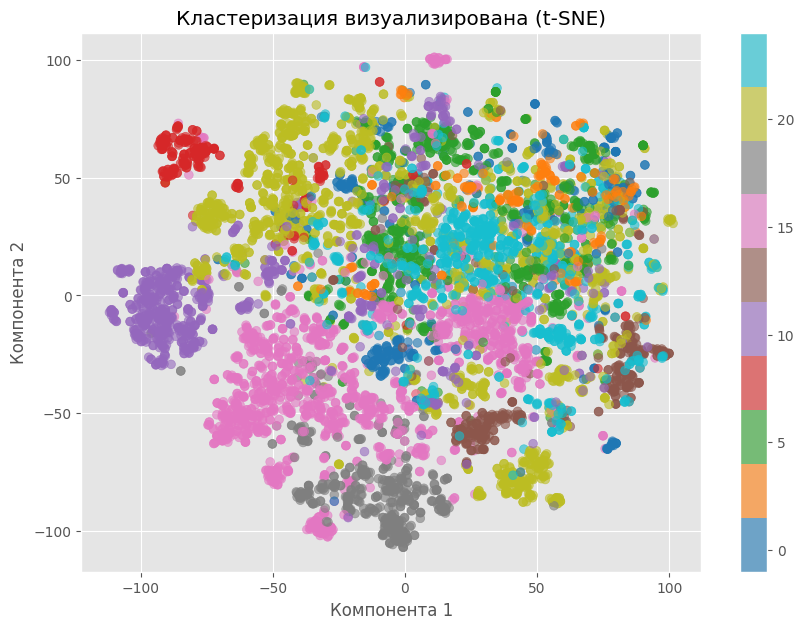

AttributeError: module 'umap' has no attribute 'UMAP'

In [14]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap

# Настраиваем стиль
plt.style.use('ggplot')

def plot_clusters_2d(embeddings, labels, method='pca'):
    if method == 'pca':
        reducer = PCA(n_components=2)
        reduced = reducer.fit_transform(embeddings)
        title = "PCA"
    elif method == 'tsne':
        reducer = TSNE(n_components=2, perplexity=25, learning_rate=1000, random_state=42)
        reduced = reducer.fit_transform(embeddings)
        title = "t-SNE"
    elif method == 'umap':
        reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='cosine', random_state=42)
        reduced = reducer.fit_transform(embeddings)
        title = "UMAP"
    else:
        raise ValueError("method должен быть 'pca', 'tsne' или 'umap'")

    # Визуализация
    plt.figure(figsize=(10, 7))
    scatter = plt.scatter(
        reduced[:, 0],
        reduced[:, 1],
        c=labels,
        cmap='tab10',
        s=40,
        alpha=0.6,
    )
    plt.colorbar(scatter)
    plt.title(f"Кластеризация визуализирована ({title})")
    plt.xlabel("Компонента 1")
    plt.ylabel("Компонента 2")
    plt.show()

# Пример вызова:
plot_clusters_2d(embeddings, goods_df['target'], method='pca')
plot_clusters_2d(embeddings, goods_df['target'], method='tsne')
plot_clusters_2d(embeddings, goods_df['target'], method='umap')

In [43]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Вычисляем центроиды кластеров
unique_labels = np.unique(labels[labels != -1])
centroids = {}

for lab in unique_labels:
    cluster_emb = embeddings[labels == lab]
    centroids[lab] = np.mean(cluster_emb, axis=0)

def predict_cluster(text, model, tokenizer, centroids, threshold=0.75):
    """Определяет кластер по максимальному косинусному сходству с центроидом"""
    emb = embed_bert_cls(text, model, tokenizer).reshape(1, -1)
    sims = {lab: cosine_similarity(emb, centroid.reshape(1, -1))[0][0]
            for lab, centroid in centroids.items()}
    best_label, best_sim = max(sims.items(), key=lambda x: x[1])

    if best_sim < threshold:
        return None, best_sim  # объект не похож ни на один кластер
    return best_label, best_sim

# Пример использования:
test_name = "Шпинат свежий"
pred_label, similarity = predict_cluster(test_name, model, tokenizer, centroids)

if pred_label is not None:
    print(f"'{test_name}' принадлежит кластеру {pred_label} (сходство {similarity:.2f})")
else:
    print(f"'{test_name}' не подходит ни к одному кластеру (max similarity={similarity:.2f})")

'Шпинат свежий' принадлежит кластеру 218 (сходство 0.96)
